In [318]:
import sys
sys.path.append('../../')
import random
import uuid
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from core.evaluator import lvdt_evaluator, vc_evaluator

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.operators.sampling.rnd import IntegerRandomSampling

from joblib import Parallel, delayed
from pymoo.core.problem import JoblibParallelization

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


### 4 objective function

In [ ]:
# LVDT/VC 4 objective function problem
class PSVCProblem(ElementwiseProblem):
    
    def __init__(self, **kwargs):

        x_min = np.zeros(7)
        x_max = np.zeros(7)

        x_min[0], x_max[0] = 2 , 8     # NLI
        x_min[1], x_max[1] = 10, 18     # DI
        x_min[2], x_max[2] = 15, 25     # LI

        x_min[3], x_max[3] = 3 ,  9     # NLO
        x_min[4], x_max[4] = 25, 40     # DO
        x_min[5], x_max[5] = 10, 30     # LO
        
        x_min[6], x_max[6] = 15 , 20     # DIO

        super().__init__(n_var=7,n_obj=4, n_constr=2, xl=x_min, xu=x_max, **kwargs)
    
       
    def _evaluate(self, x, out, *args, **kwargs):
        iter_datetime = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{uuid.uuid4().hex[:12]}"
        
        lvdt_json_filename      = "../config/v0_typeG_lvdt.json"
        vc_json_filename        = "../config/v0_typeG_vc.json"
        lvdt_iter_filename      = "../data/4obj/config/iteration_lvdt_" + iter_datetime + ".json"
        vc_iter_filename        = "../data/4obj/config/iteration_vc_" + iter_datetime + ".json"
        lvdt_output_dir         = "../data/4obj/result"
        vc_output_dir           = "../data/4obj/result"
        lvdt_output_filename    = "typeG_LVDT_" +iter_datetime +".h5"
        vc_output_filename      = "typeG_VC_" +iter_datetime +".h5"
        f1, f2 = lvdt_evaluator(x, 
                                lvdt_json_filename, 
                                lvdt_iter_filename, 
                                lvdt_output_dir, 
                                lvdt_output_filename)
        f3, f4 = vc_evaluator(x,
                              vc_json_filename, 
                              vc_iter_filename, 
                              vc_output_dir, 
                              vc_output_filename)
        g1 = x[6]*2 + x[5] - 70
        g2 = 40 - x[6]*2 - x[5]

        out["F"] = np.column_stack([-f1, f2,-f3, f4]) 
        out["G"] = np.column_stack([g1, g2])

PSVCalgorithm = NSGA2(pop_size=10, 
                  sampling=IntegerRandomSampling(),
                  crossover=SBX(prob=1.0, eta=20, vtype = float, repair = RoundingRepair()),
                  mutation=PM(eta=20, vtype = float, repair = RoundingRepair()),
                  eliminate_duplicates=True)

In [ ]:
# manually optimal params = [6, 14, 20, 7, 34, 25, 17.5]
n_jobs = 10
parallel = Parallel(n_jobs=n_jobs)
runner = JoblibParallelization(parallel, delayed)

problem = PSVCProblem(elementwise_runner = runner)

res = minimize(problem, 
               PSVCalgorithm, 
               ('n_gen', 1), 
               seed=1, 
               verbose=True,
               save_history=True)
print(f"Execution time: {res.exec_time}")

### 2 objective function - LVDT

In [319]:
class PSProblem(ElementwiseProblem):
    
    def __init__(self, **kwargs):

        x_min = np.zeros(7)
        x_max = np.zeros(7)

        x_min[0], x_max[0] = 2 , 8     # NLI
        x_min[1], x_max[1] = 10, 18     # DI
        x_min[2], x_max[2] = 15, 25     # LI

        x_min[3], x_max[3] = 3 ,  9     # NLO
        x_min[4], x_max[4] = 25, 40     # DO
        x_min[5], x_max[5] = 10, 30     # LO
        
        x_min[6], x_max[6] = 15 , 20     # DIO

        super().__init__(n_var=7,n_obj=2, n_constr=2, xl=x_min, xu=x_max, **kwargs)
    
       
    def _evaluate(self, x, out, *args, **kwargs):
        iter_datetime = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{uuid.uuid4().hex[:12]}"
        
        lvdt_json_filename      = "../config/v0_typeG_lvdt.json"
        lvdt_iter_filename      = "../data/2obj-lvdt/config/iteration_lvdt_" + iter_datetime + ".json"
        lvdt_output_dir         = "../data/2obj-lvdt/result"
        lvdt_output_filename    = "typeG_LVDT_" +iter_datetime +".h5"

        f1, f2 = lvdt_evaluator(x, 
                                lvdt_json_filename, 
                                lvdt_iter_filename, 
                                lvdt_output_dir, 
                                lvdt_output_filename)

        g1 = x[6]*2 + x[5] - 70
        g2 = 40 - x[6]*2 - x[5]

        out["F"] = np.column_stack([-f1, f2]) 
        out["G"] = np.column_stack([g1, g2])

PSalgorithm = NSGA2(pop_size=50, 
                  sampling=IntegerRandomSampling(),
                  crossover=SBX(prob=0.9, eta=25, vtype = float, repair = RoundingRepair()),
                  mutation=PM(prob = 0.3,eta=50, vtype = float, repair = RoundingRepair()),
                  eliminate_duplicates=True)

def run_femm_vc(params):
    time = datetime.now().strftime("%Y%m%d%H%M%S") + f"_{uuid.uuid4().hex[:12]}"
    f3, f4 = vc_evaluator(
        params = params,
        input_json_filename     = f'../config/v0_typeG_vc.json',
        iter_json_filename      = f'../data/2obj-vc/config/iteration_vc_{time}.json',
        output_dir              = f"../data/2obj-vc/result",
        output_filename         = f'typeG_VC_{time}.h5')
    return [f3, f4]


In [320]:
# manually optimal params = [6, 14, 20, 7, 34, 25, 17.5]
n_jobs = 15
parallel = Parallel(n_jobs=n_jobs)
runner = JoblibParallelization(parallel, delayed)

problem = PSProblem(elementwise_runner = runner)

res = minimize(problem, 
               PSalgorithm, 
               ('n_gen', 50), 
               seed=1, 
               verbose=True,
               save_history=True)
print(f"Execution time: {res.exec_time}")

import pickle
with open("../solutions/lvdt_50gen.pkl", "wb") as f:
    pickle.dump(res, f)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       50 |      6 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      100 |     11 |  0.000000E+00 |  0.000000E+00 |  0.2587245245 |         ideal
     3 |      150 |      9 |  0.000000E+00 |  0.000000E+00 |  0.0477606559 |             f
     4 |      200 |     12 |  0.000000E+00 |  0.000000E+00 |  0.1004410592 |         ideal
     5 |      250 |     11 |  0.000000E+00 |  0.000000E+00 |  0.0362820906 |         ideal
     6 |      300 |     10 |  0.000000E+00 |  0.000000E+00 |  0.1364463621 |         ideal
     7 |      350 |      8 |  0.000000E+00 |  0.000000E+00 |  0.0115243481 |         ideal
     8 |      400 |     10 |  0.000000E+00 |  0.000000E+00 |  0.0370145970 |         ideal
     9 |      450 |     14 |  0.000000E+00 |  0.000000E+00 |  0.0232354956 |             f
    10 |      500 |      4 |  0.000000E+00 |  0.000000E+00 |  0.1418428962 |         ideal

In [340]:
vc_result = None
with open("../solutions/lvdt_50gen.pkl", "rb") as f:
    lvdt_result = pickle.load(f)
opt_X = lvdt_result.X
n_job = len(opt_X)
if n_job <20:
    vc_result = Parallel(n_jobs=n_job)(delayed(run_femm_vc)(x) for x in opt_X)
else:
    print("Too many jobs to run in parallel")

In [346]:
table_label = ["NLI", "DI",  "LI", "NLO", "DO", "LO", "DIO", "S", "NLE", "MF", "FVI"]

manually_optimal_params = [6, 14, 20, 7, 34, 25, 17.5, 8.4226,0.4824, 1.8479, 8.8649]

with open("../solutions/lvdt_50gen.pkl", "rb") as f:
    lvdt_result = pickle.load(f)
algo_input = [x.tolist() for x in lvdt_result.X ]
algo_value = [[-round(f_list[0], 4), round(f_list[1], 4)] for f_list in lvdt_result.F]  
algo_value_vc = [[round(x[0],4), round(x[1],4)] for x in vc_result]
algo_optimal_params = [inp + val + vc for inp, val, vc in zip(algo_input, algo_value, algo_value_vc)]

with open("../solutions/opt_50gen.txt", "w") as f:
    f.write(" ".join(f"{col:<12}" for col in table_label) + "\n")
    f.write(" ".join(f"{val:<12}" for val in manually_optimal_params) + "\n")
    for row in algo_optimal_params:
        f.write(" ".join(f"{val:<12}" for val in row) + "\n")

#### visualization

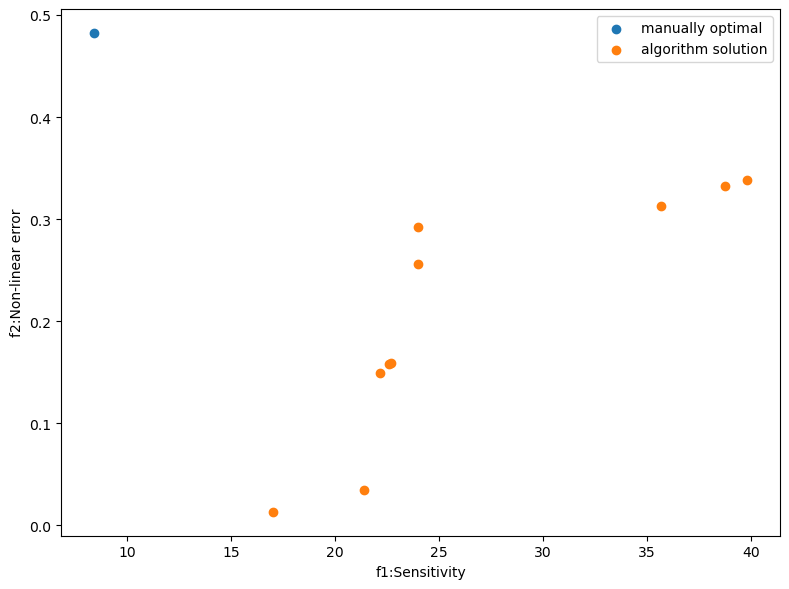

In [603]:
solution = "../solutions/lvdt_50gen.pkl"
# solution = "../solutions/lvdt_30gen.pkl"
with open(solution, "rb") as f:
    lvdt_result = pickle.load(f)

opt_F = lvdt_result.F
opt_X = lvdt_result.X

manually_optimal_F = [ 8.4226,0.4824, 1.8479, 8.8649]
plt.figure(figsize=(8,6))
plt.scatter(manually_optimal_F[0], manually_optimal_F[1], label = 'manually optimal')
plt.scatter(-opt_F[:,0], opt_F[:,1], label = 'algorithm solution')
plt.xlabel('f1:Sensitivity')
plt.ylabel('f2:Non-linear error')
# plt.title('Pareto front')
plt.legend()
plt.tight_layout()
plt.savefig("../solutions/pareto_front_50gen.pdf")


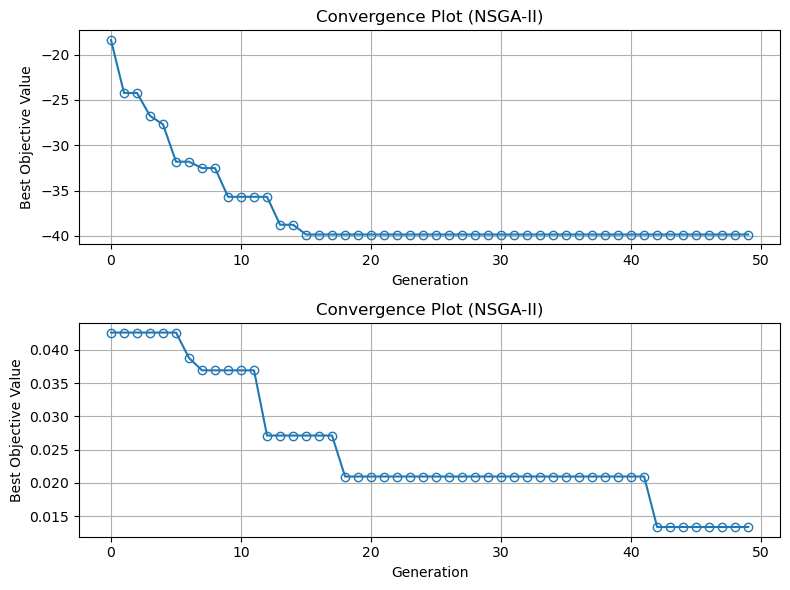

In [604]:
n_gen = len(lvdt_result.history)
f_min_values = [gen.opt.get("F").min(axis=0) for gen in lvdt_result.history]
f_min_values = np.array(f_min_values)  # 转换为 NumPy 数组

plt.figure (figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(f_min_values[:, 0], marker = 'o',markerfacecolor='none', label="Min f1 (Sensitivity)")
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(f_min_values[:, 1], marker = 'o',markerfacecolor='none', label="Min f2 (Non-linear error)")
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.grid()
plt.tight_layout()
plt.savefig("../solutions/convergence_plot_50gen.pdf")


#### History input and output visualization

In [544]:
solutions = ["../solutions/lvdt_50gen.pkl",
            "../solutions/lvdt_30gen.pkl",]

with open(solutions[0], "rb") as f:
    lvdt_result = pickle.load(f)
    
input = []
output = []
for gen, algo in enumerate(lvdt_result.history):
    pop = algo.pop
    X = pop.get("X")
    F = pop.get("F")
    input.append(X)
    output.append(F)


In [545]:
nli_dict = dict()
di_dict = dict()
li_dict = dict()
nlo_dict = dict()
do_dict = dict()
lo_dict = dict()
dio_dict = dict()
for x in input: # 50 generations
    nli_dict[str(i)] = nli = []
    di_dict[str(i)] = di = []
    li_dict[str(i)] = li = []
    nlo_dict[str(i)] = nlo = []
    do_dict[str(i)] = do = []
    lo_dict[str(i)] = lo = []
    dio_dict[str(i)] = dio = []

    for y in x: # 50 individuals
        i +=1
        nli.append(y[0])
        di.append(y[1])
        li.append(y[2])
        nlo.append(y[3])
        do.append(y[4])
        lo.append(y[5])
        dio.append(y[6])

sensi_dict = dict()
nle_dict = dict()
for m in output: # 50 generations
    sensi_dict[str(i)] = sensi = []
    nle_dict[str(i)] = nle = []

    for n in m: # 50 individuals
        i +=1
        sensi.append(n[0])
        nle.append(n[1])


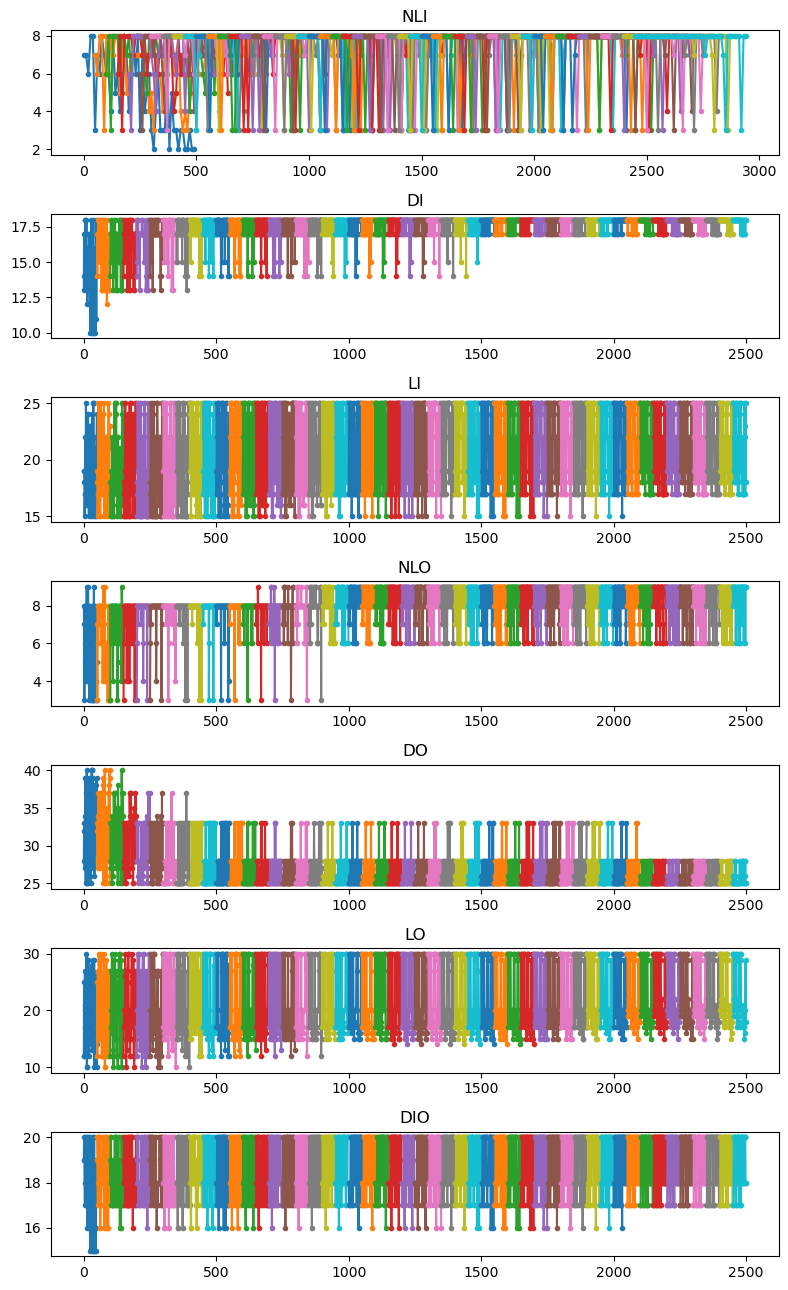

In [ ]:
x_num = 50
plt.figure(figsize=(8, 13))
plt.subplot(7,1,1)
xaxis_nli = np.array(range(x_num))
for key, value in nli_dict.items():
    plt.plot(xaxis_nli, value, marker = '.')
    xaxis_nli += x_num
plt.title("NLI")

plt.subplot(7,1,2)
xaxis_di = np.array(range(x_num))
for key, value in di_dict.items():
    plt.plot(xaxis_di, value, marker = '.')
    xaxis_di += x_num
plt.title("DI")

plt.subplot(7,1,3)
xaxis_li = np.array(range(x_num))
for key, value in li_dict.items():
    plt.plot(xaxis_li, value, marker = '.')
    xaxis_li += x_num
plt.title("LI")

plt.subplot(7,1,4)
xaxis_nlo = np.array(range(x_num))
for key, value in nlo_dict.items():
    plt.plot(xaxis_nlo, value, marker = '.')
    xaxis_nlo += x_num
plt.title("NLO")

plt.subplot(7,1,5)
xaxis_do = np.array(range(x_num))
for key, value in do_dict.items():
    plt.plot(xaxis_do, value, marker = '.')
    xaxis_do += x_num
plt.title("DO")

plt.subplot(7,1,6)
xaxis_lo = np.array(range(x_num))
for key, value in lo_dict.items():
    plt.plot(xaxis_lo, value, marker = '.')
    xaxis_lo += x_num
plt.title("LO")

plt.subplot(7,1,7)
xaxis_dio = np.array(range(x_num))
for key, value in dio_dict.items():
    plt.plot(xaxis_dio, value, marker = '.')
    xaxis_dio += x_num
plt.title("DIO")
plt.tight_layout()
# plt.savefig("input.pdf", format='pdf')


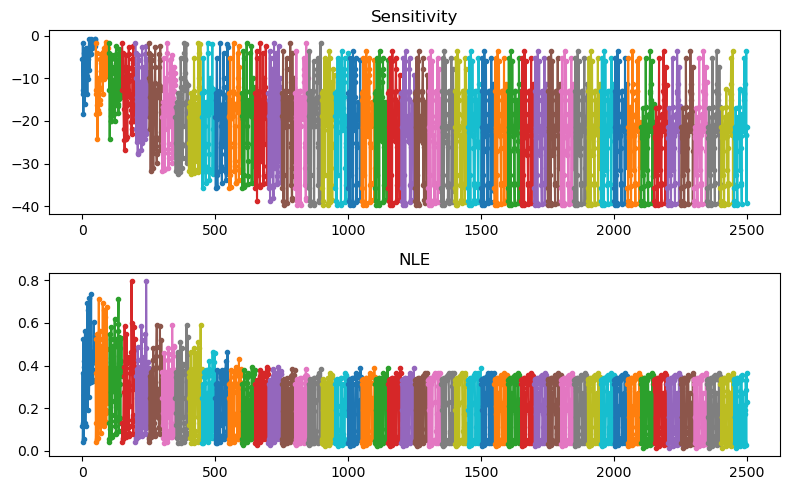

In [547]:
plt.figure(figsize=(8, 5))
plt.subplot(2,1,1)
xaxis_sensi = np.array(range(x_num))

for key, value in sensi_dict.items():
    plt.plot(xaxis_sensi, value, marker = '.')
    xaxis_sensi += x_num
plt.title("Sensitivity")

plt.subplot(2,1,2)
xaxis_nle = np.array(range(x_num))
for key, value in nle_dict.items():
    plt.plot(xaxis_nle, value, marker = '.')
    xaxis_nle += x_num
plt.title("NLE")
plt.tight_layout()

